<a href="https://colab.research.google.com/github/kavya5cloud/CervicalCancerDetection/blob/main/Cervical_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install gdown

In [3]:
import gdown

file_id = "1LcHX4aA0ChibSbLsjP3MvTR96Tc37DYu"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "datasets.zip",
    quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=1LcHX4aA0ChibSbLsjP3MvTR96Tc37DYu
From (redirected): https://drive.google.com/uc?id=1LcHX4aA0ChibSbLsjP3MvTR96Tc37DYu&confirm=t&uuid=67552c33-3066-457e-804a-23c4c2545b49
To: /content/datasets.zip
100%|██████████| 6.92G/6.92G [01:48<00:00, 63.9MB/s]


'datasets.zip'

In [4]:
import os

print(os.listdir())

['.config', 'datasets.zip', 'sample_data']


In [5]:
!unzip datasets.zip -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/047_cyt03.dat  
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/047_nuc01.dat  
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/047_nuc02.dat  
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/047_nuc03.dat  
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/048.bmp  
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/048_cyt01.dat  
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/048_nuc01.dat  
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/049.bmp  
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/049_cyt01.dat  
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/049_nuc01.dat  
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/050.bmp  
  inflating: dataset/sipakmed_wsi_pap_smear/benign_Metaplastic/050_cyt01.dat  
  inflating: datase

In [6]:
import os

print(os.listdir("dataset"))

['herlev_pap_smear', 'sipakmed_fci_pap_smear', 'sipakmed_wsi_pap_smear']


In [7]:
import os

dataset_path = "dataset/sipakmed_fci_pap_smear"

print(os.listdir(dataset_path))

['normal_Parabasal', 'benign_Metaplastic', 'normal_Superficial_Intermediate', 'abnormal_Koilocytotic', 'abnormal_Dyskeratotic']


In [8]:
import os
import cv2
import numpy as np

IMG_SIZE = 128

data = []
labels = []

dataset_path = "dataset/sipakmed_fci_pap_smear"

categories = os.listdir(dataset_path)

print("Classes:", categories)

for category in categories:

    folder = os.path.join(
        dataset_path,
        category
    )

    label = categories.index(category)

    for img in os.listdir(folder):

        img_path = os.path.join(
            folder,
            img
        )

        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(
            image,
            (IMG_SIZE, IMG_SIZE)
        )

        data.append(image)
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Images shape:", data.shape)
print("Labels shape:", labels.shape)

Classes: ['normal_Parabasal', 'benign_Metaplastic', 'normal_Superficial_Intermediate', 'abnormal_Koilocytotic', 'abnormal_Dyskeratotic']
Images shape: (4049, 128, 128, 3)
Labels shape: (4049,)


In [9]:
data = data / 255.0

print("Min value:", data.min())
print("Max value:", data.max())

Min value: 0.054901960784313725
Max value: 1.0


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3239, 128, 128, 3)
Testing data: (810, 128, 128, 3)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 3)
    )
)

model.add(MaxPooling2D())

model.add(
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    )
)

model.add(MaxPooling2D())

model.add(Flatten())

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dense(
        len(set(labels)),
        activation="softmax"
    )
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,965 (28.20 MB)

 Trainable params: 7,392,965 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.5366 - loss: 1.2368 - val_accuracy: 0.7012 - val_loss: 0.8549
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7079 - loss: 0.7736 - val_accuracy: 0.7506 - val_loss: 0.6633
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7638 - loss: 0.6335 - val_accuracy: 0.7556 - val_loss: 0.6284
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7916 - loss: 0.5580 - val_accuracy: 0.8346 - val_loss: 0.4923
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8206 - loss: 0.4932 - val_accuracy: 0.7630 - val_loss: 0.6583
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8407 - loss: 0.4377 - val_accuracy: 0.8358 - val_loss: 0.4982
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8509 - loss: 0.4057 - val_accuracy: 0.8519 - val_loss: 0.4344
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8787 - loss: 0.3596 - val_acc

In [13]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8654 - loss: 0.4056
Accuracy: 0.86543208360672


In [14]:
model.save("cervical_cancer_model.h5")

In [15]:
model.save("cervical_cancer_model.keras")

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation="relu"
)(x)

predictions = Dense(
    len(set(labels)),
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
history = model.fit(
    datagen.flow(
        X_train,
        y_train,
        batch_size=32
    ),
    epochs=15,
    validation_data=(X_test, y_test)
)

Epoch 1/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 70s 501ms/step - accuracy: 0.7515 - loss: 0.6310 - val_accuracy: 0.8370 - val_loss: 0.4547
Epoch 2/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - accuracy: 0.8537 - loss: 0.3971 - val_accuracy: 0.8284 - val_loss: 0.4774
Epoch 3/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 16s 160ms/step - accuracy: 0.8750 - loss: 0.3442 - val_accuracy: 0.8741 - val_loss: 0.3451
Epoch 4/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - accuracy: 0.8762 - loss: 0.3385 - val_accuracy: 0.8827 - val_loss: 0.3552
Epoch 5/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.8898 - loss: 0.2895 - val_accuracy: 0.8642 - val_loss: 0.3951
Epoch 6/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.8990 - loss: 0.2715 - val_accuracy: 0.8679 - val_loss: 0.3861
Epoch 7/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.9009 - loss: 0.2656 - val_accuracy: 0.8753 - val_loss: 0.4226
Epoch 8/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.9086 - loss: 0

In [19]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8531 - loss: 0.5071
Accuracy: 0.8530864119529724


In [20]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [22]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [23]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [26]:
history = model.fit(
    datagen.flow(
        X_train,
        y_train,
        batch_size=32
    ),
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 50s 340ms/step - accuracy: 0.8154 - loss: 0.6684 - val_accuracy: 0.7136 - val_loss: 1.2946
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.8740 - loss: 0.3662 - val_accuracy: 0.8037 - val_loss: 0.7592
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.9009 - loss: 0.2804 - val_accuracy: 0.8222 - val_loss: 0.6205
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step - accuracy: 0.9077 - loss: 0.2484 - val_accuracy: 0.7741 - val_loss: 0.7960
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.9225 - loss: 0.2073 - val_accuracy: 0.7395 - val_loss: 0.8961
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.9284 - loss: 0.1987 - val_accuracy: 0.7852 - val_loss: 0.7701


In [27]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8222 - loss: 0.6205
Accuracy: 0.8222222328186035


In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

In [29]:
history = model.fit(
    datagen.flow(
        X_train,
        y_train,
        batch_size=32
    ),
    epochs=15,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.9077 - loss: 0.2625 - val_accuracy: 0.8457 - val_loss: 0.4903
Epoch 2/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 16s 159ms/step - accuracy: 0.9188 - loss: 0.2166 - val_accuracy: 0.8593 - val_loss: 0.4876
Epoch 3/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.9231 - loss: 0.1925 - val_accuracy: 0.8321 - val_loss: 0.6028
Epoch 4/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.9401 - loss: 0.1812 - val_accuracy: 0.8123 - val_loss: 0.6601
Epoch 5/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.9352 - loss: 0.1712 - val_accuracy: 0.8556 - val_loss: 0.5747


In [30]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Final Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8593 - loss: 0.4876
Final Accuracy: 0.8592592477798462


In [31]:
from tensorflow.keras.layers import Dropout

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(128, activation="relu")(x)

x = Dropout(0.5)(x)

predictions = Dense(
    len(set(labels)),
    activation="softmax"
)(x)

In [32]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2
)

In [33]:
callbacks=[early_stop, lr_reduce]

In [34]:
import os
import cv2
import numpy as np

IMG_SIZE = 224

data = []
labels = []

dataset_path = "dataset/sipakmed_fci_pap_smear"

categories = os.listdir(dataset_path)

print("Classes:", categories)

for category in categories:

    folder = os.path.join(dataset_path, category)

    label = categories.index(category)

    for img in os.listdir(folder):

        img_path = os.path.join(folder, img)

        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        data.append(image)
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Images shape:", data.shape)
print("Labels shape:", labels.shape)

Classes: ['normal_Parabasal', 'benign_Metaplastic', 'normal_Superficial_Intermediate', 'abnormal_Koilocytotic', 'abnormal_Dyskeratotic']
Images shape: (4049, 224, 224, 3)
Labels shape: (4049,)


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
dataset_path = "dataset/sipakmed_fci_pap_smear"

IMG_SIZE = 224
BATCH_SIZE = 32

print("Dataset path:", dataset_path)
print("Image size:", IMG_SIZE)

Dataset path: dataset/sipakmed_fci_pap_smear
Image size: 224


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="training"
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="validation"
)

Found 3241 images belonging to 5 classes.
Found 808 images belonging to 5 classes.


In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

predictions = Dense(
    train_generator.num_classes,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

print("Model built successfully")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built successfully


In [5]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 1,846,149 (7.04 MB)

 Non-trainable params: 576,448 (2.20 MB)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2
)

print("Callbacks ready")

Callbacks ready


In [7]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 133s 964ms/step - accuracy: 0.6911 - loss: 0.8094 - val_accuracy: 0.2661 - val_loss: 2.4556 - learning_rate: 1.0000e-04
Epoch 2/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 66s 648ms/step - accuracy: 0.8679 - loss: 0.3852 - val_accuracy: 0.4171 - val_loss: 1.9027 - learning_rate: 1.0000e-04
Epoch 3/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 58s 566ms/step - accuracy: 0.8911 - loss: 0.3065 - val_accuracy: 0.4270 - val_loss: 1.8889 - learning_rate: 1.0000e-04
Epoch 4/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 56s 546ms/step - accuracy: 0.9053 - loss: 0.2672 - val_accuracy: 0.5965 - val_loss: 1.6498 - learning_rate: 1.0000e-04
Epoch 5/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 56s 549ms/step - accuracy: 0.9192 - loss: 0.2265 - val_accuracy: 0.4740 - val_loss: 2.0910 - learning_rate: 1.0000e-04
Epoch 6/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 57s 558ms/step - accuracy: 0.9343 - loss: 0.1916 - val_accuracy: 0.3589 - val_loss: 2.2396 - learning_rate: 1.0000e-04
Epoch 7/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 54s 5

In [8]:
loss, accuracy = model.evaluate(validation_generator)

print("Final Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 586ms/step - accuracy: 0.5990 - loss: 1.6567
Final Accuracy: 0.5990098714828491


In [9]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

validation_generator_eval = validation_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="validation",
    shuffle=False
)

Found 808 images belonging to 5 classes.


In [10]:
loss, accuracy = model.evaluate(
    validation_generator_eval
)

print("Correct Final Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6139 - loss: 1.5561
Correct Final Accuracy: 0.6138613820075989


In [11]:
import os
import shutil
import random

dataset_path = "dataset/sipakmed_fci_pap_smear"

train_dir = "dataset_split/train"
val_dir = "dataset_split/val"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

split_ratio = 0.8

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    images = os.listdir(class_path)

    random.shuffle(images)

    split_index = int(len(images) * split_ratio)

    train_images = images[:split_index]
    val_images = images[split_index:]

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

    for img in train_images:

        src = os.path.join(class_path, img)
        dst = os.path.join(train_dir, class_name, img)

        if not os.path.exists(dst):
            shutil.copy(src, dst)

    for img in val_images:

        src = os.path.join(class_path, img)
        dst = os.path.join(val_dir, class_name, img)

        if not os.path.exists(dst):
            shutil.copy(src, dst)

print("Dataset split completed")

Dataset split completed


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

Found 3212 images belonging to 5 classes.
Found 837 images belonging to 5 classes.


In [13]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 79s 778ms/step - accuracy: 0.9200 - loss: 0.2410 - val_accuracy: 0.5317 - val_loss: 1.1932 - learning_rate: 3.0000e-05
Epoch 2/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 44s 438ms/step - accuracy: 0.9306 - loss: 0.2073 - val_accuracy: 0.6081 - val_loss: 1.0234 - learning_rate: 3.0000e-05
Epoch 3/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 44s 439ms/step - accuracy: 0.9415 - loss: 0.1787 - val_accuracy: 0.6404 - val_loss: 1.1428 - learning_rate: 3.0000e-05
Epoch 4/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 46s 453ms/step - accuracy: 0.9390 - loss: 0.1684 - val_accuracy: 0.8065 - val_loss: 0.5805 - learning_rate: 3.0000e-05
Epoch 5/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 45s 444ms/step - accuracy: 0.9455 - loss: 0.1508 - val_accuracy: 0.8124 - val_loss: 0.5197 - learning_rate: 3.0000e-05
Epoch 6/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 46s 457ms/step - accuracy: 0.9465 - loss: 0.1521 - val_accuracy: 0.8984 - val_loss: 0.2650 - learning_rate: 3.0000e-05
Epoch 7/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 44s 43

In [14]:
loss, accuracy = model.evaluate(validation_generator)

print("Final Accuracy:", accuracy)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8984 - loss: 0.2650
Final Accuracy: 0.8984468579292297


In [15]:
for layer in base_model.layers[-60:]:
    layer.trainable = True

print("Last 60 layers unfrozen")

Last 60 layers unfrozen


In [16]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    train_generator,
    epochs=8,
    validation_data=validation_generator,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/8
101/101 ━━━━━━━━━━━━━━━━━━━━ 96s 669ms/step - accuracy: 0.8848 - loss: 0.3207 - val_accuracy: 0.8913 - val_loss: 0.2610 - learning_rate: 1.0000e-05
Epoch 2/8
101/101 ━━━━━━━━━━━━━━━━━━━━ 47s 465ms/step - accuracy: 0.9026 - loss: 0.2569 - val_accuracy: 0.9188 - val_loss: 0.2371 - learning_rate: 1.0000e-05
Epoch 3/8
101/101 ━━━━━━━━━━━━━━━━━━━━ 45s 448ms/step - accuracy: 0.9134 - loss: 0.2492 - val_accuracy: 0.9116 - val_loss: 0.2486 - learning_rate: 1.0000e-05
Epoch 4/8
101/101 ━━━━━━━━━━━━━━━━━━━━ 47s 463ms/step - accuracy: 0.9166 - loss: 0.2339 - val_accuracy: 0.9164 - val_loss: 0.2431 - learning_rate: 1.0000e-05
Epoch 5/8
101/101 ━━━━━━━━━━━━━━━━━━━━ 45s 445ms/step - accuracy: 0.9178 - loss: 0.2239 - val_accuracy: 0.9247 - val_loss: 0.2226 - learning_rate: 3.0000e-06
Epoch 6/8
101/101 ━━━━━━━━━━━━━━━━━━━━ 46s 457ms/step - accuracy: 0.9262 - loss: 0.2086 - val_accuracy: 0.9355 - val_loss: 0.2013 - learning_rate: 3.0000e-06
Epoch 7/8
101/101 ━━━━━━━━━━━━━━━━━━━━ 45s 443ms/ste

In [18]:
loss, accuracy = model.evaluate(validation_generator)

print("Final Accuracy:", accuracy)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9415 - loss: 0.1858
Final Accuracy: 0.9414575695991516


In [19]:
model.save("final_cervical_cancer_model.keras")

print("Model saved successfully")

Model saved successfully


27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 217ms/step


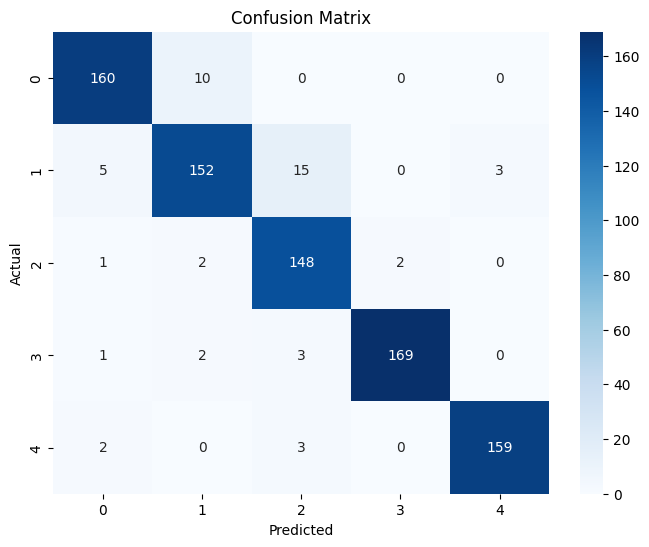

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = validation_generator.classes

y_pred_probs = model.predict(validation_generator)

y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=validation_generator.class_indices.keys()
    )
)

                                 precision    recall  f1-score   support

          abnormal_Dyskeratotic       0.95      0.94      0.94       170
          abnormal_Koilocytotic       0.92      0.87      0.89       175
             benign_Metaplastic       0.88      0.97      0.92       153
               normal_Parabasal       0.99      0.97      0.98       175
normal_Superficial_Intermediate       0.98      0.97      0.98       164

                       accuracy                           0.94       837
                      macro avg       0.94      0.94      0.94       837
                   weighted avg       0.94      0.94      0.94       837

